# 04 — Exploratory Data Analysis

Working from the cleaned dataset (442 sensors, 1,567 units), this notebook explores
distributional structure before any feature selection or modeling: how spread out are sensor
scales, how correlated are sensors with each other, and does a naive single-sensor view already
hint at failure signal?


In [1]:

import sys
sys.path.insert(0, "../src")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import visualization as viz

df = pd.read_csv("../data/processed/secom_cleaned.csv")
sensor_cols = [c for c in df.columns if c not in ("Time", "Pass/Fail")]
print("Cleaned shape:", df.shape, "| sensors:", len(sensor_cols))


Cleaned shape: (1567, 444) | sensors: 442


## Sensor scale variety

Sensors come from different instruments (voltages, flow rates, counts), so raw scales vary enormously — this matters for model choice (tree models are scale-invariant, linear models are not).

count     442.000000
mean       76.764380
std       445.539047
min         0.000104
25%         0.049557
50%         1.157615
75%         9.518634
max      6550.267099
dtype: float64


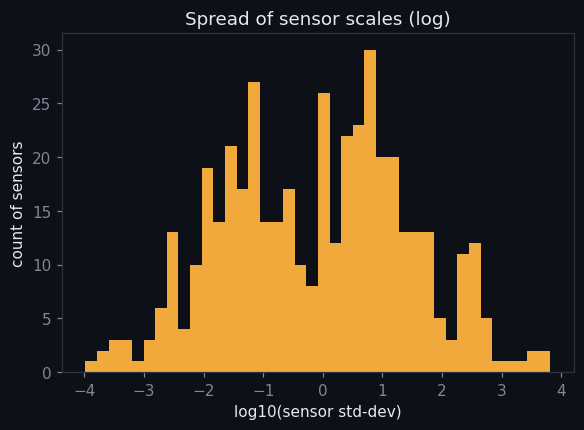

In [2]:

scales = df[sensor_cols].std()
print(scales.describe())

fig, ax = plt.subplots(figsize=(6,4))
ax.hist(np.log10(scales.replace(0, np.nan).dropna()), bins=40, color=viz.PALETTE['accent'])
ax.set_xlabel("log10(sensor std-dev)")
ax.set_ylabel("count of sensors")
ax.set_title("Spread of sensor scales (log)")
plt.show()


**Observation:** sensor standard deviations span several orders of magnitude. This confirms
the Random Forest choice for the primary model (notebook 06) — it doesn't require feature
scaling — while the Logistic Regression baseline will need `StandardScaler` applied first.

## Pairwise sensor correlation

With 442 sensors from the same physical process, many are likely to be highly correlated (redundant instrumentation, shared upstream causes).

In [3]:

corr = df[sensor_cols].corr().abs().to_numpy(copy=True)
# exclude self-correlation
np.fill_diagonal(corr, 0)
high_corr_pairs = int((corr > 0.95).sum()) // 2
print(f"Sensor pairs with |correlation| > 0.95: {high_corr_pairs}")
print(f"Sensor pairs with |correlation| > 0.99: {int((corr > 0.99).sum()) // 2}")


Sensor pairs with |correlation| > 0.95: 271
Sensor pairs with |correlation| > 0.99: 127


**Observation:** a large number of near-duplicate sensor pairs exist. This is expected in fab
data (multiple probes on the same subsystem) and is exactly why we lean on the **model's**
feature importance ranking rather than univariate correlation with the label alone — a Random
Forest naturally down-weights redundant, correlated features relative to what a simple
per-sensor correlation table would suggest.

## A first look at single-sensor separation

Before modeling, sanity-check whether *any* single sensor visibly separates pass/fail on its own.

In [4]:

fail_mask = df['Pass/Fail'] == 1
pass_mask = df['Pass/Fail'] == -1

# quick univariate screen: rank sensors by standardized mean gap between pass/fail
gap = {}
for c in sensor_cols:
    p_std = df.loc[pass_mask, c].std()
    if p_std == 0 or np.isnan(p_std):
        continue
    gap[c] = abs(df.loc[fail_mask, c].mean() - df.loc[pass_mask, c].mean()) / p_std

gap = pd.Series(gap).sort_values(ascending=False)
print("Top 5 sensors by standardized pass/fail mean gap:")
print(gap.head(5))


Top 5 sensors by standardized pass/fail mean gap:
59     0.641383
103    0.621553
348    0.602682
510    0.557190
431    0.550490
dtype: float64


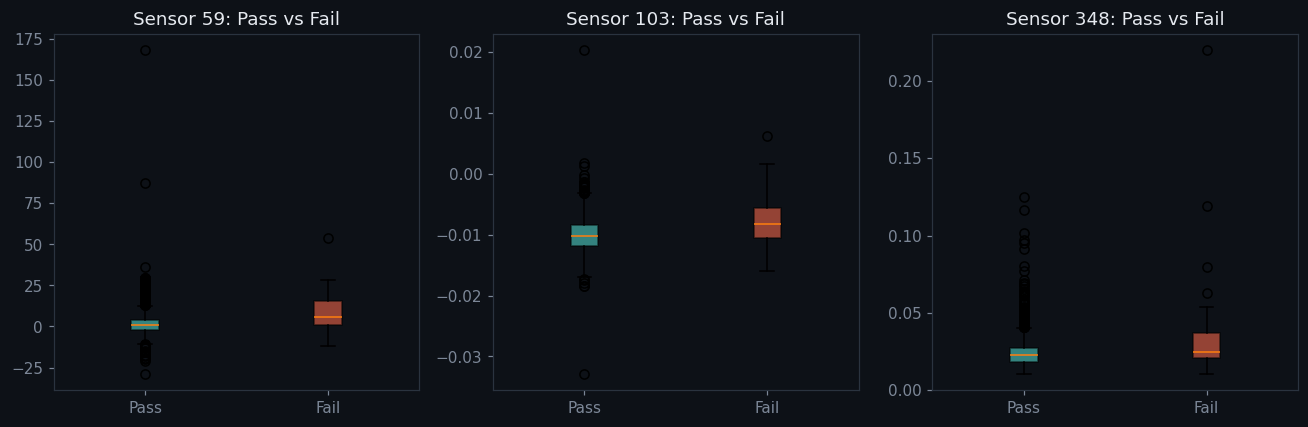

In [5]:

fig, axes = plt.subplots(1, 3, figsize=(12,4))
for ax, sensor in zip(axes, gap.head(3).index):
    viz.plot_sensor_boxplot(df.loc[pass_mask, sensor].dropna(),
                             df.loc[fail_mask, sensor].dropna(),
                             sensor_name=sensor, ax=ax)
plt.tight_layout()
plt.show()


**Observation:** even the sensors with the largest simple mean-gap show heavily overlapping
distributions between pass and fail — there is no single sensor that cleanly separates the two
classes. This is expected for a real fab process and motivates a **multivariate model**
(notebook 06) rather than simple threshold rules, plus formal statistical testing
(notebook 07) rather than trusting a ranked list by eye.